In [31]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

# Загрузка изображения в оттенках серого

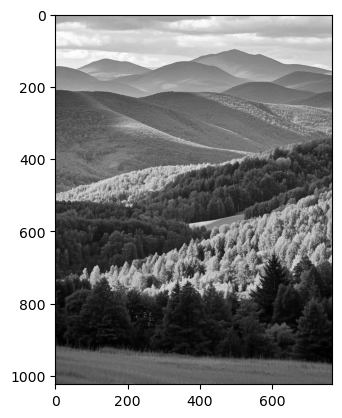

In [32]:
image = cv2.imread('hills.jpg')
image_grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 
plt.imshow(image_grey, cmap='gray')

# Построение гистограммы

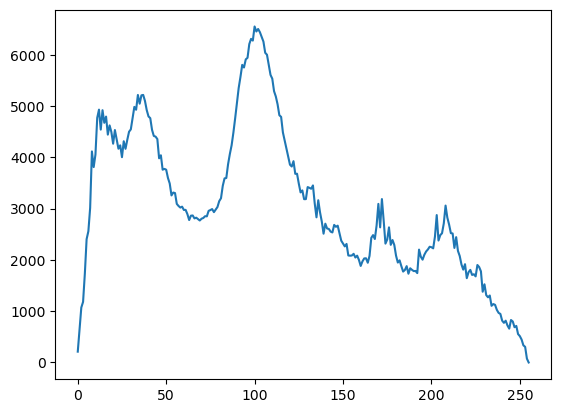

In [33]:
histSize = 256
histRange = (0, 256)
accumulate = False

grey_hist = cv2.calcHist([image_grey], [0], None, [histSize], histRange, accumulate=accumulate)

plt.plot(grey_hist)

# Алгоритм гамма-коррекции с параметром <1, >1


In [34]:
def gamma_correction(image, gamma):
    return ((image / 255) ** gamma * 255).astype("uint8") 

gamma_light = gamma_correction(image_grey, 0.3)
gamma_dark = gamma_correction(image_grey, 2.7)

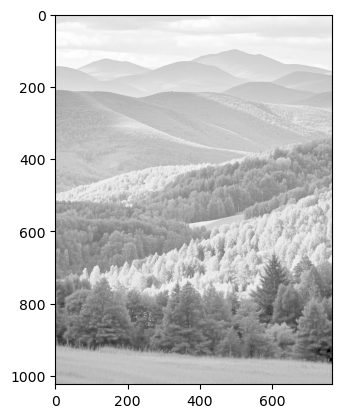

In [35]:
plt.imshow(gamma_light, cmap='gray')

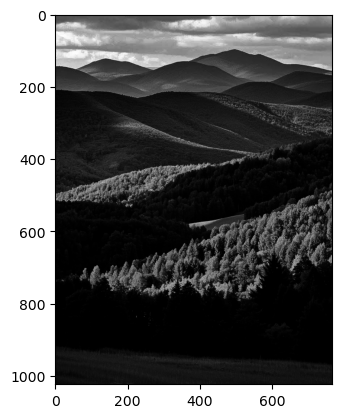

In [36]:
plt.imshow(gamma_dark, cmap='gray')

# MSE, SSIM

SSIM: 0.4051372125649518


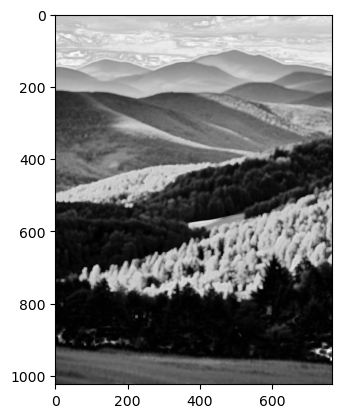

In [37]:
(ssim, diff) = structural_similarity(image_grey, gamma_dark, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

plt.imshow(diff, cmap='gray')

In [38]:
mse = mean_squared_error(image_grey, gamma_dark)
mse

np.float64(4443.708438873291)

SSIM: 0.6635798981072363


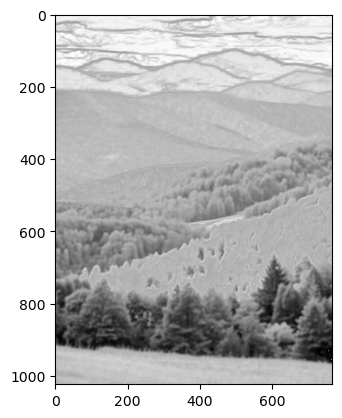

In [39]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image_grey, gamma_light, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

plt.imshow(diff, cmap='gray')

In [40]:
mse = mean_squared_error(image_grey, gamma_light)
mse

np.float64(7118.243516286214)

# Алгоритм статистической цветокоррекции на основе статистики eq_gray

In [41]:
mean = image_grey.mean()
std = image_grey.std()
print(mean, std)

104.29468154907227 63.93017082117789


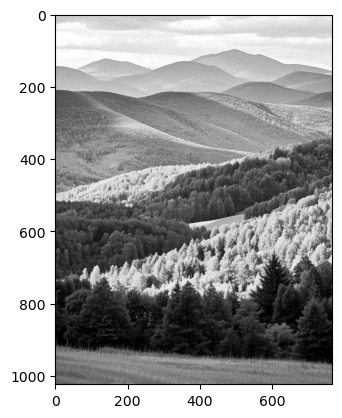

In [42]:
eq_gray = cv2.equalizeHist(image_grey)
plt.imshow(eq_gray, cmap='gray')

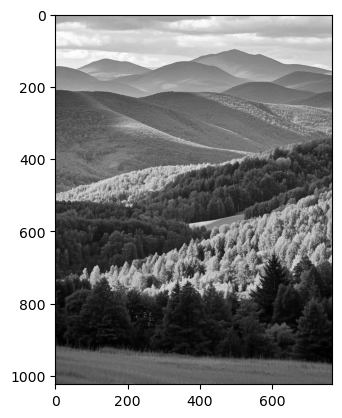

In [43]:
plt.imshow(image_grey, cmap='gray')

In [44]:
mean_eq = eq_gray.mean()
std_eq = eq_gray.std()
print(mean_eq, std_eq)

128.07973988850912 73.51141123095152


In [45]:
image_stat = mean_eq + (image_grey.astype(float) - mean) * std_eq / std
image_stat = np.clip(image_stat, 0, 255).astype("uint8")
print(image_stat.mean(), image_stat.std())

126.57915369669597 71.5984332827985


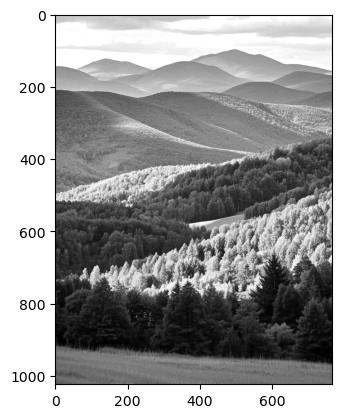

In [46]:
plt.imshow(image_stat, cmap='gray')

# Пороговая фильтрация

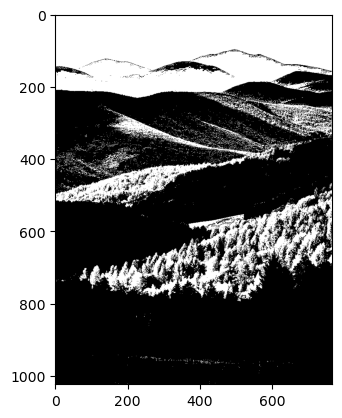

In [57]:
_, thresh_bin = cv2.threshold(image_grey, 128, 255, cv2.THRESH_BINARY)
plt.imshow(thresh_bin, cmap='gray')

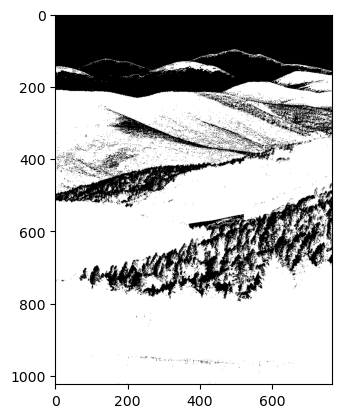

In [58]:
_, thresh_inv = cv2.threshold(image_grey, 128, 255, cv2.THRESH_BINARY_INV)
plt.imshow(thresh_inv, cmap='gray')

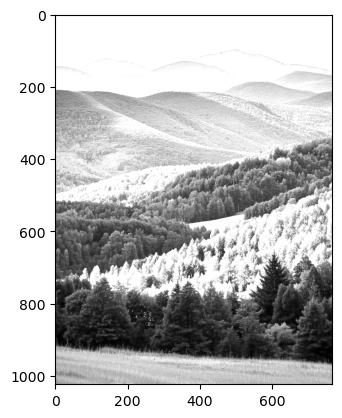

In [65]:
_, thresh_trunc = cv2.threshold(image_grey, 128, 255, cv2.THRESH_TRUNC)
plt.imshow(thresh_trunc, cmap='gray')

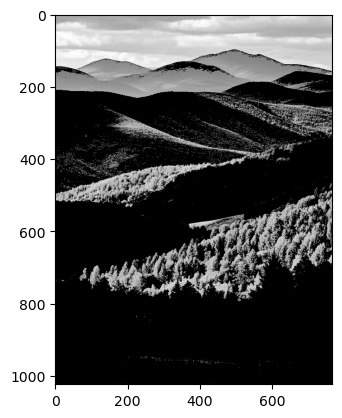

In [66]:
_, thresh_tozero = cv2.threshold(image_grey, 128, 255, cv2.THRESH_TOZERO)
plt.imshow(thresh_tozero, cmap='gray')

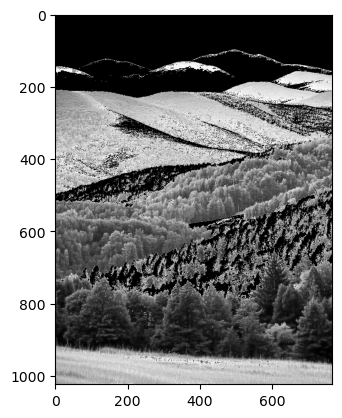

In [67]:
_, thresh_tozero_inv = cv2.threshold(image_grey, 128, 255, cv2.THRESH_TOZERO_INV)
plt.imshow(thresh_tozero_inv, cmap='gray')

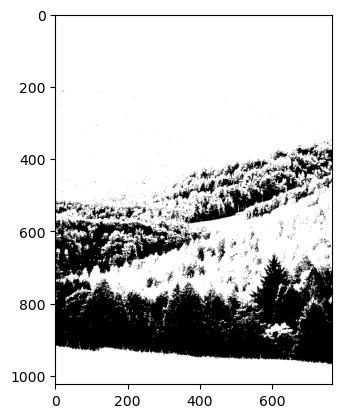

In [68]:
_, thresh_50 = cv2.threshold(image_grey, 50, 255, cv2.THRESH_BINARY)
plt.imshow(thresh_50, cmap='gray')

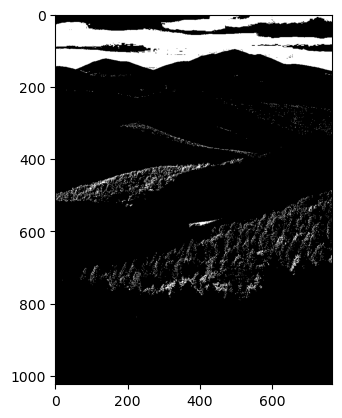

In [73]:
_, thresh_200 = cv2.threshold(image_grey, 200, 255, cv2.THRESH_BINARY)
plt.imshow(thresh_200, cmap='gray')